# Introduction au Machine Learning

##### Importation des packages 

In [77]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

##### On charge le dataset et on le découvre

In [78]:
digits = load_digits()
print(f"Colonnes du dataset : {digits.keys()}\n")
print(f"Targets : {digits.target_names}\n")
print(f"Première images : {digits.images[0]}\n")
print(f"Nombre d'images : {digits.images.shape[0]}")

Colonnes du dataset : dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

Targets : [0 1 2 3 4 5 6 7 8 9]

Première images : [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

Nombre d'images : 1797


Plotting a some of the data

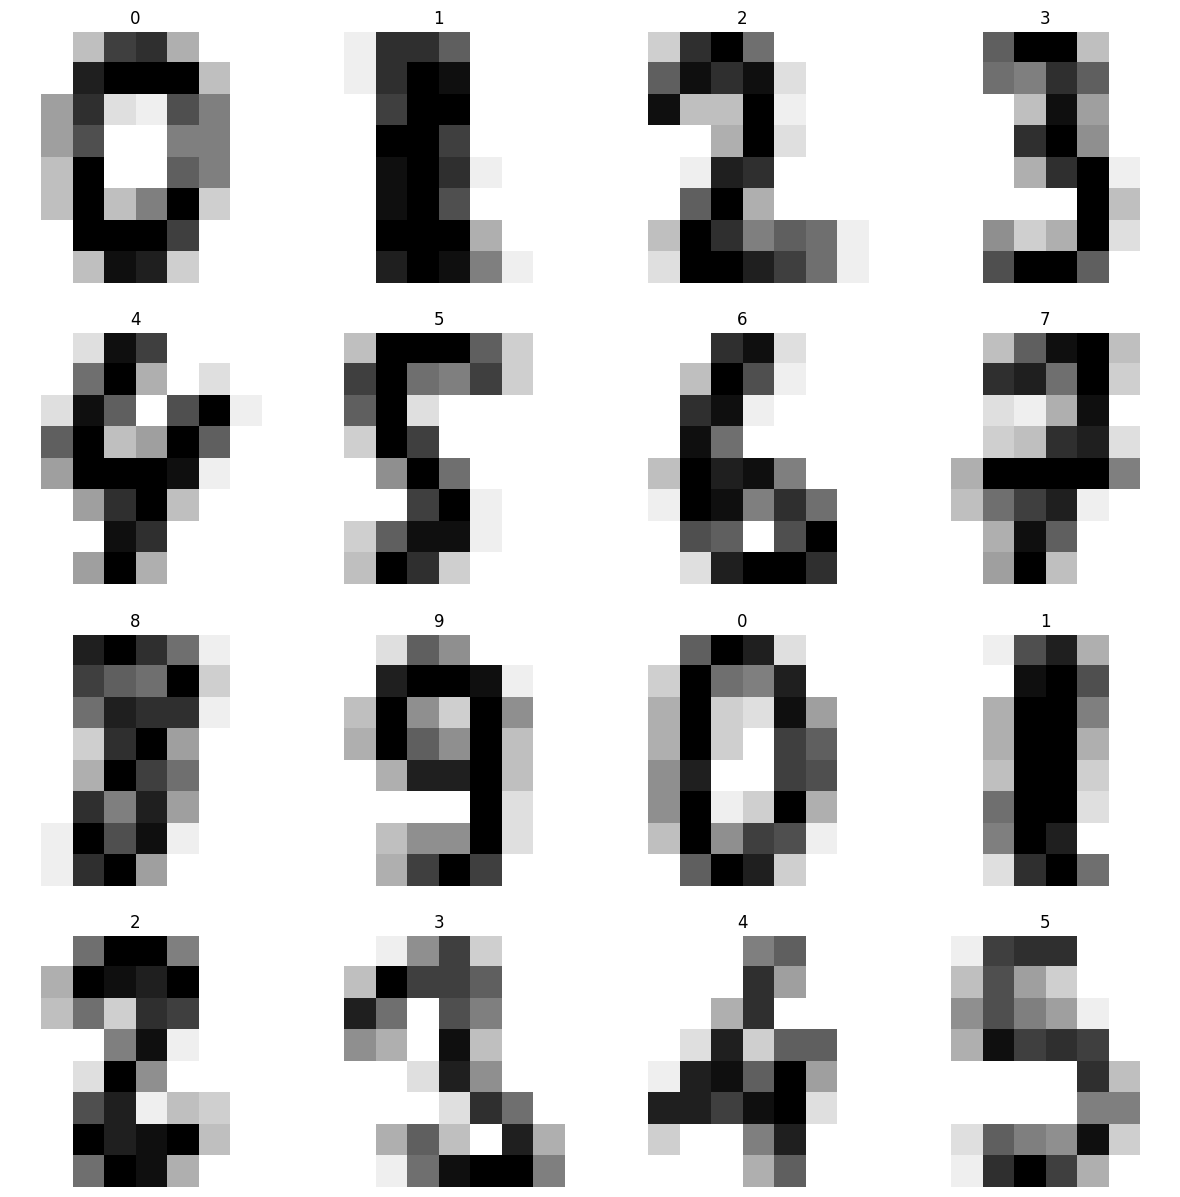

In [79]:
def plot_multi(data, y):
    '''Plots 16 digits'''
    nplots = 16
    nb_classes = len(np.unique(y))
    cur_class = 0
    fig = plt.figure(figsize=(15,15))
    for j in range(nplots):
        plt.subplot(4,4,j+1)
        to_display_idx = np.random.choice(np.where(y == cur_class)[0])
        plt.imshow(data[to_display_idx].reshape((8,8)), cmap='binary')
        plt.title(cur_class)
        plt.axis('off')
        cur_class = (cur_class + 1) % nb_classes
    plt.show()


plot_multi(digits.data, digits.target)

Defining our X and Y variables

In [80]:
X = digits.data
Y = digits.target

print(f"Our Data : {X}")
print(f"Our Labels : {Y}")

Our Data : [[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
Our Labels : [0 1 2 ... 8 9 8]


Normalizing

In [81]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Normalized data {X_scaled}")

Normalized data [[0.     0.     0.3125 ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.625  0.     0.    ]
 [0.     0.     0.     ... 1.     0.5625 0.    ]
 ...
 [0.     0.     0.0625 ... 0.375  0.     0.    ]
 [0.     0.     0.125  ... 0.75   0.     0.    ]
 [0.     0.     0.625  ... 0.75   0.0625 0.    ]]


Print dataset shape

In [82]:
print(f"Feature matrix shape: {X_scaled.shape}. Max value = {np.max(X_scaled)}, Min value = {np.min(X_scaled)}, Mean value = {np.mean(X_scaled)}")
print(f"Labels shape: {Y.shape}")

Feature matrix shape: (1797, 64). Max value = 1.0, Min value = 0.0, Mean value = 0.3071437902148591
Labels shape: (1797,)


Dimension Reduction

In [83]:
pca = PCA( n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca)

[[ 0.06113739 -1.37811679]
 [ 0.37573724  1.35466438]
 [ 0.37052705  0.67597542]
 ...
 [ 0.61313384  0.52192977]
 [-0.23032906 -0.82527455]
 [-0.02290219 -0.34818667]]


Plotting 64D to 2D

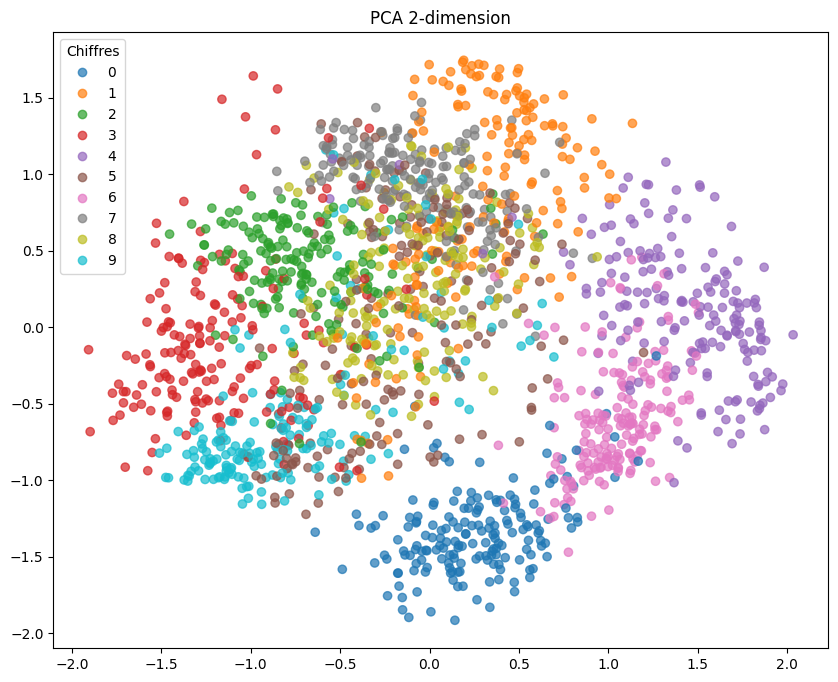

In [84]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", c=digits.target, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Chiffres")
plt.title("PCA 2-dimension")
plt.show()

Inversing the Transform

In [85]:
X_inv = pca.inverse_transform(X_pca)
print(X_inv)

mse = mean_squared_error(X_inv, X_scaled)
print(f"Mean Square Error : {mse}")


[[0.         0.00946877 0.26348319 ... 0.65213233 0.14619304 0.01177475]
 [0.         0.04976824 0.28674691 ... 0.1613499  0.09536657 0.02803269]
 [0.         0.03704303 0.2643524  ... 0.27722503 0.10510903 0.02306353]
 ...
 [0.         0.02507195 0.20371565 ... 0.28342922 0.09769079 0.01882151]
 [0.         0.03085158 0.3491105  ... 0.58212018 0.14993748 0.01959988]
 [0.         0.03220525 0.31841984 ... 0.483868   0.13504039 0.02049011]]
Mean Square Error : 0.0534121549200043


Plotting the Difference

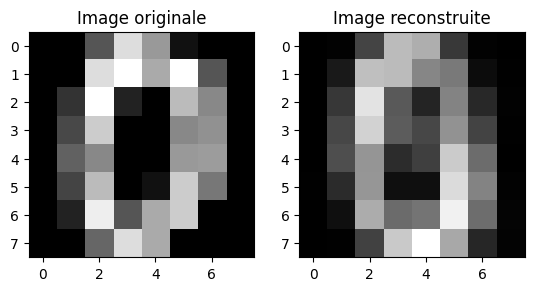

In [86]:
plt.subplot(1,2,1)
img0 = X_scaled[0].reshape(8,8)
plt.imshow(img0,cmap='gray')
plt.title("Image originale")

plt.subplot(1,2,2)
img1 = X_inv[0].reshape(8,8)
plt.imshow(img1,cmap='gray')
plt.title("Image reconstruite")

plt.show()

Analysing the Varience to find the best dimension reduction

Dimension where 95% or data is retained : 29


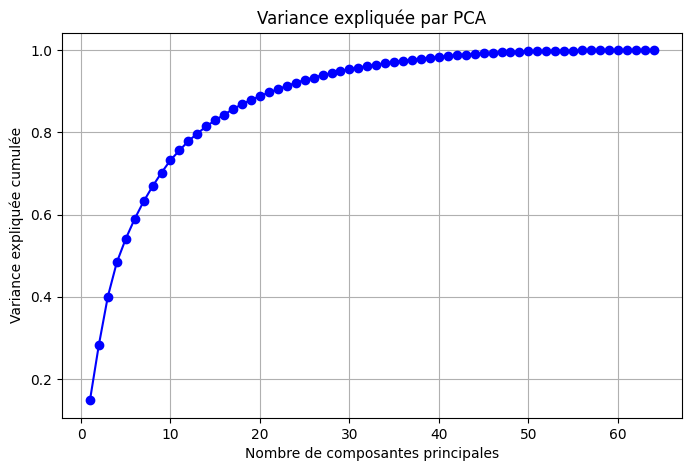

In [87]:
pca = PCA()
pca.fit(X_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)  
print(f"Dimension where 95% or data is retained : {64-len(explained_variance[explained_variance>=0.95])}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, X_scaled.shape[1]+1), explained_variance, marker='o', linestyle='-', color='blue')
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée par PCA")
plt.grid()
plt.show()

Plotting the Images for different dimension transformation

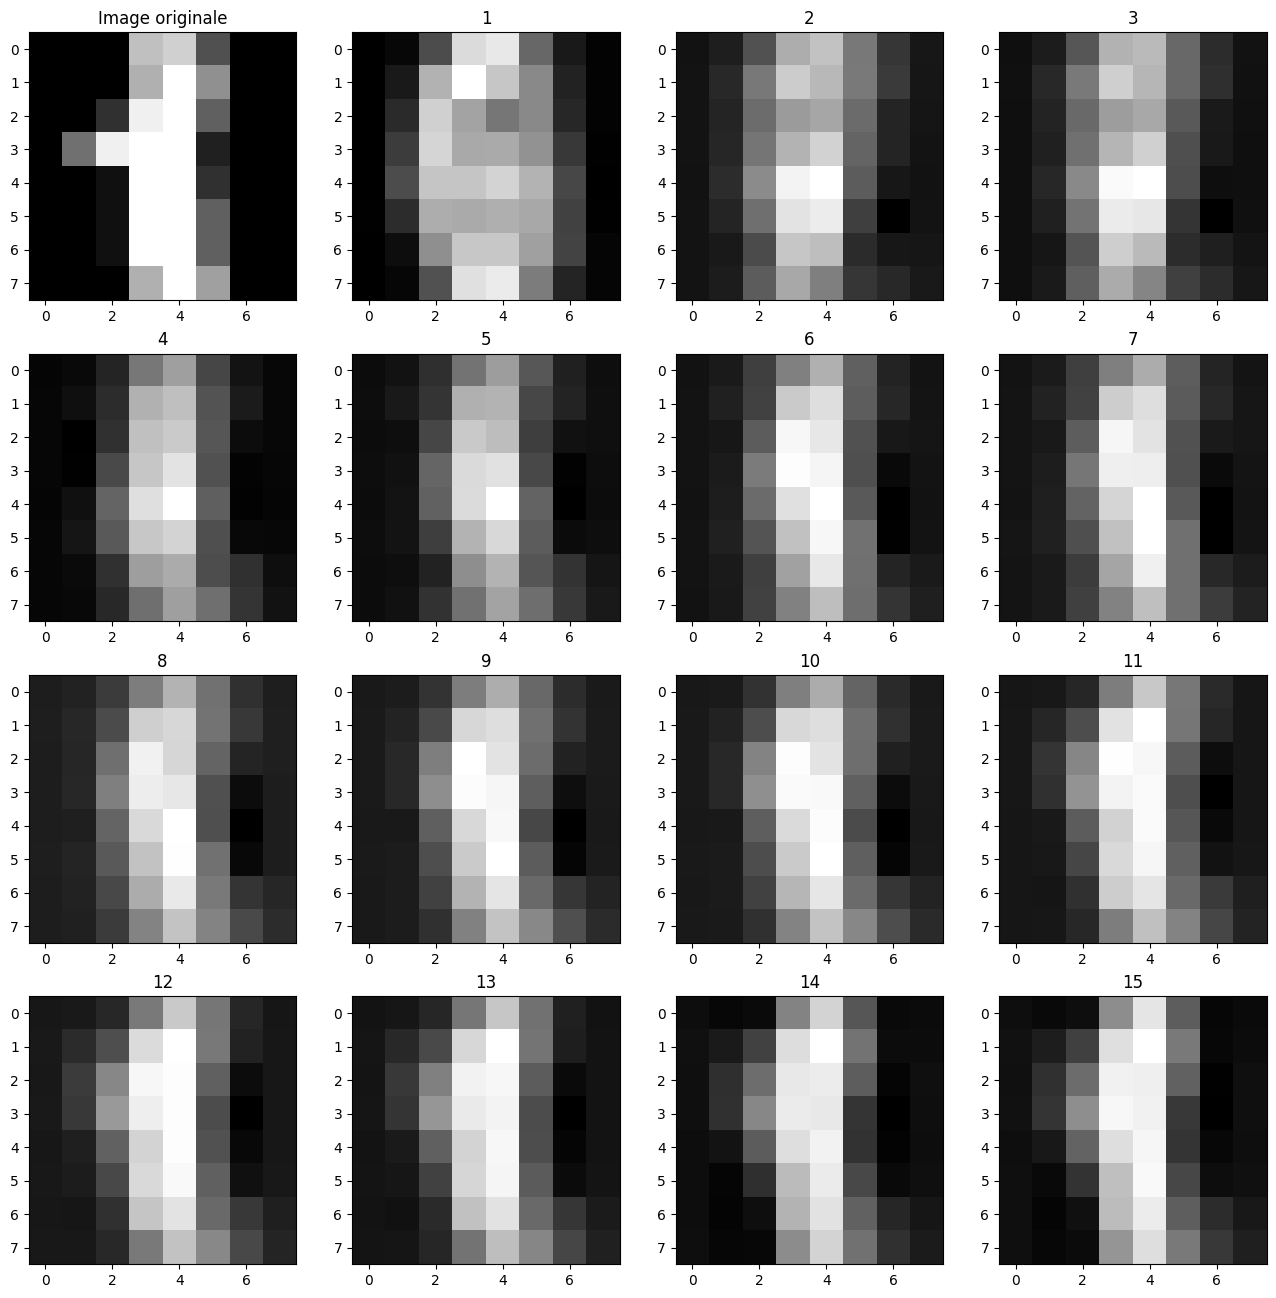

In [88]:
plt.figure(figsize=(16,16))
plt.subplot(4,4,1)
plt.imshow(X[1].reshape(8,8), cmap='gray')
plt.title("Image originale")

for j in range(1,16):
    plt.subplot(4,4,j+1)
    pca = PCA(n_components=j)
    X_pca = pca.fit_transform(X_scaled) 
    X_inv = pca.inverse_transform(X_pca)
    plt.imshow(X_inv[1].reshape(8,8),cmap='gray')
    plt.title(j)
plt.show()

##### Feature engineering partitionnement en fonction des zones

In [89]:
def extract_zone_features(X):
    n = X.shape[0]
    res = np.zeros((n, 3))
    for i in range(n):
        zone1 = np.mean(X[i, 0:24])
        zone2 = np.mean(X[i, 24:40])
        zone3 = np.mean(X[i, 40:64])
        res[i, :] = [zone1, zone2, zone3]
    return res

F_zones = extract_zone_features(X_scaled)

print(f"Feature matrix F_zones shape: {F_zones.shape}")

Feature matrix F_zones shape: (1797, 3)


##### Feature pour la detection des bords

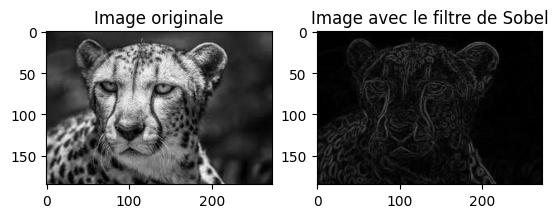

In [90]:
from skimage.filters import sobel
img = plt.imread("../../img/chita.jpg")
img_edges = sobel(img)
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Image originale")
plt.subplot(1,2,2)
plt.imshow(img_edges, cmap='gray')
plt.title("Image avec le filtre de Sobel")
plt.savefig("../../img/chita_edges.png")

In [91]:
def apply_sobel(X):
    n = X.shape[0]
    sobel_mean = np.zeros(n)
    for i in range(n):
        img = X[i].reshape(8, 8)
        sobel_img = sobel(img)
        sobel_mean[i] = np.mean(sobel_img)
    return sobel_mean

F_edges = apply_sobel(X)
print(f"Dimensions après traitement :",F_edges.shape)

Dimensions après traitement : (1797,)
